In [379]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [380]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('tmdb_5000_movies.csv')
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [381]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [382]:
# drop homepage, id, overview, tagline, title, status. 
df.drop(columns=['homepage', 'id', 'overview', 'tagline', 'title', 'status'], inplace=True)

In [383]:
df[df['release_date'].isnull()]
df[df['runtime'].isnull()]


,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count
2656,15000000,"[{""id"": 18, ""name"": ""Drama""}]","[{""id"": 717, ""name"": ""pope""}, {""id"": 5565, ""na...",it,Chiamatemi Francesco - Il Papa della gente,0.738646,"[{""name"": ""Taodue Film"", ""id"": 45724}]","[{""iso_3166_1"": ""IT"", ""name"": ""Italy""}]",2015-12-03,0,NaN,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",7.3,12
4140,2,"[{""id"": 99, ""name"": ""Documentary""}]","[{""id"": 6027, ""name"": ""music""}, {""id"": 225822,...",en,"To Be Frank, Sinatra at 100",0.050625,"[{""name"": ""Eyeline Entertainment"", ""id"": 60343}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2015-12-12,0,NaN,[],0.0,0


In [384]:
df = df.drop(index=4553)

In [385]:
df.head()

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",6.1,2124


In [386]:
def extract_names(df, columns):
    for col in columns:
        df[col] = df[col].apply(ast.literal_eval)
        df[col] = df[col].apply(lambda x: [i['name'] for i in x])
    return df

columns = ['genres', 'keywords', 'spoken_languages', 'production_companies', 'production_countries']
df = extract_names(df, columns)

In [387]:
df.head()

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...",en,Avatar,150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",7.2,11800
1,300000000,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,[English],6.9,4500
2,245000000,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...",en,Spectre,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,"[Français, English, Español, Italiano, Deutsch]",6.3,4466
3,250000000,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,[English],7.6,9106
4,260000000,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...",en,John Carter,43.926995,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,[English],6.1,2124


In [388]:
df[df['spoken_languages'] == '[]'].__len__()

df['spoken_languages'].value_counts()

spoken_languages
[English]                       3171
[English, Español]               127
[English, Français]              114
[]                                85
[Español, English]                54
                                ... 
[English, Italiano, svenska]       1
[svenska]                          1
[ελληνικά]                         1
[Italiano, Español]                1
[Polski, English]                  1
Name: count, Length: 530, dtype: int64

In [389]:
df['vote_average'].unique()

array([ 7.2,  6.9,  6.3,  7.6,  6.1,  5.9,  7.4,  7.3,  5.7,  5.4,  7. ,
        6.5,  6.4,  6.2,  7.1,  5.8,  6.6,  7.5,  5.5,  6.7,  6.8,  6. ,
        5.1,  7.8,  5.6,  5.2,  8.2,  7.7,  5.3,  8. ,  4.8,  4.9,  7.9,
        8.1,  4.7,  5. ,  4.2,  4.4,  4.1,  3.7,  3.6,  3. ,  3.9,  4.3,
        4.5,  3.4,  4.6,  8.3,  3.5,  4. ,  2.3,  3.2,  0. ,  3.8,  2.9,
        8.5,  1.9,  3.1,  3.3,  2.2,  0.5,  9.3,  8.4,  2.7, 10. ,  1. ,
        2. ,  2.8,  9.5,  2.6,  2.4])

In [390]:
top_n_config = {
    'genres': None,
    'spoken_languages': None,
    'production_countries': None,
    'production_companies': 20,
    'keywords': 50
}

def get_dummies_for_columns(df, top_n_config):
    result = {}
    for col, top_n in top_n_config.items():
        exploded = df[col].explode()
        if top_n:
            top_values = exploded.value_counts().nlargest(top_n).index
            exploded = exploded[exploded.isin(top_values)]
        dummies = pd.get_dummies(exploded)
        result[col] = dummies.groupby(level=0).max().reindex(df.index, fill_value=0)
    return result

dummies = get_dummies_for_columns(df, top_n_config)

In [391]:
for col, dummy_df in dummies.items():
    df = df.join(dummy_df, rsuffix=f'_{col}')

In [392]:
df.head()

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,,??????,Afrikaans,Bahasa indonesia,Bamanankan,Bosanski,Català,Cymraeg,Dansk,Deutsch,Eesti,English,Español,Esperanto,Français,Gaeilge,Galego,Hrvatski,Italiano,Kiswahili,Latin,Magyar,Nederlands,No Language,Norsk,Polski,Português,Pусский,Română,Slovenčina,Slovenščina,Somali,Srpski,Tiếng Việt,Türkçe,Wolof,isiZulu,shqip,suomi,svenska,Íslenska,Český,ελληνικά,Український,български език,қазақ,עִבְרִית,اردو,العربية,فارسی,پښتو,हिन्दी,বাংলা,ਪੰਜਾਬੀ,தமிழ்,తెలుగు,ภาษาไทย,ქართული,广州话 / 廣州話,日本語,普通话,한국어/조선말,Afghanistan,Algeria,Angola,Argentina,Aruba,Australia,Austria,Bahamas,Belgium,Bhutan,Bolivia,Bosnia and Herzegovina,Brazil,Bulgaria,Cambodia,Cameroon,Canada,Chile,China,Colombia,Cyprus,Czech Republic,Denmark,Dominica,Dominican Republic,Ecuador,Egypt,Fiji,Finland,France,Germany,Greece,Guadaloupe,Guyana,Hong Kong,Hungary,Iceland,India,Indonesia,Iran,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,Kyrgyz Republic,Lebanon,Libyan Arab Jamahiriya,Lithuania,Luxembourg,Malaysia,Malta,Mexico,Monaco,Morocco,Netherlands,New Zealand,Nigeria,Norway,Pakistan,Panama,Peru,Philippines,Poland,Portugal,Romania,Russia,Serbia,Serbia and Montenegro,Singapore,Slovakia,Slovenia,South Africa,South Korea,Spain,Sweden,Switzerland,Taiwan,Thailand,Tunisia,Turkey,Ukraine,United Arab Emirates,United Kingdom,United States of America,Canal+,Columbia Pictures,Columbia Pictures Corporation,DreamWorks SKG,Dune Entertainment,Fox Searchlight Pictures,Lionsgate,Metro-Goldwyn-Mayer (MGM),Miramax Films,New Line Cinema,Paramount Pictures,Regency Enterprises,Relativity Media,Touchstone Pictures,Twentieth Century Fox Film Corporation,United Artists,Universal Pictures,Village Roadshow Pictures,Walt Disney Pictures,Warner Bros.,3d,aftercreditsstinger,airplane,alien,based on comic book,based on novel,based on true story,biography,corruption,daughter,drug,duringcreditsstinger,dying and death,dystopia,escape,family,father son relationship,friends,friendship,high school,hospital,independent film,kidnapping,london england,los angeles,love,magic,martial arts,murder,musical,new york,nudity,party,police,prison,remake,revenge,sequel,serial killer,sex,sport,suicide,superhero,suspense,teenager,time travel,violence,wedding,woman director,world war ii
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...",en,Avatar,150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",7.2,11800,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,Fal

In [393]:
df.info(max_cols=254)

<class 'pandas.DataFrame'>
Index: 4802 entries, 0 to 4802
Data columns (total 254 columns):
 #    Column                                  Non-Null Count  Dtype  
---   ------                                  --------------  -----  
 0    budget                                  4802 non-null   int64  
 1    genres                                  4802 non-null   object 
 2    keywords                                4802 non-null   object 
 3    original_language                       4802 non-null   str    
 4    original_title                          4802 non-null   str    
 5    popularity                              4802 non-null   float64
 6    production_companies                    4802 non-null   object 
 7    production_countries                    4802 non-null   object 
 8    release_date                            4802 non-null   str    
 9    revenue                                 4802 non-null   int64  
 10   runtime                                 4800 non-null   float6

In [394]:
df.drop(columns=['', '??????'], inplace=True)

In [395]:
df.info(max_cols=254)

<class 'pandas.DataFrame'>
Index: 4802 entries, 0 to 4802
Data columns (total 252 columns):
 #    Column                                  Non-Null Count  Dtype  
---   ------                                  --------------  -----  
 0    budget                                  4802 non-null   int64  
 1    genres                                  4802 non-null   object 
 2    keywords                                4802 non-null   object 
 3    original_language                       4802 non-null   str    
 4    original_title                          4802 non-null   str    
 5    popularity                              4802 non-null   float64
 6    production_companies                    4802 non-null   object 
 7    production_countries                    4802 non-null   object 
 8    release_date                            4802 non-null   str    
 9    revenue                                 4802 non-null   int64  
 10   runtime                                 4800 non-null   float6

In [396]:
df.isna().sum()[df.isna().sum() > 0]

runtime    2
dtype: int64

In [397]:
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

In [398]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['year'] = df['release_date'].dt.year
df['month'] = df['release_date'].dt.month
df.head()

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Afrikaans,Bahasa indonesia,Bamanankan,Bosanski,Català,Cymraeg,Dansk,Deutsch,Eesti,English,Español,Esperanto,Français,Gaeilge,Galego,Hrvatski,Italiano,Kiswahili,Latin,Magyar,Nederlands,No Language,Norsk,Polski,Português,Pусский,Română,Slovenčina,Slovenščina,Somali,Srpski,Tiếng Việt,Türkçe,Wolof,isiZulu,shqip,suomi,svenska,Íslenska,Český,ελληνικά,Український,български език,қазақ,עִבְרִית,اردو,العربية,فارسی,پښتو,हिन्दी,বাংলা,ਪੰਜਾਬੀ,தமிழ்,తెలుగు,ภาษาไทย,ქართული,广州话 / 廣州話,日本語,普通话,한국어/조선말,Afghanistan,Algeria,Angola,Argentina,Aruba,Australia,Austria,Bahamas,Belgium,Bhutan,Bolivia,Bosnia and Herzegovina,Brazil,Bulgaria,Cambodia,Cameroon,Canada,Chile,China,Colombia,Cyprus,Czech Republic,Denmark,Dominica,Dominican Republic,Ecuador,Egypt,Fiji,Finland,France,Germany,Greece,Guadaloupe,Guyana,Hong Kong,Hungary,Iceland,India,Indonesia,Iran,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,Kyrgyz Republic,Lebanon,Libyan Arab Jamahiriya,Lithuania,Luxembourg,Malaysia,Malta,Mexico,Monaco,Morocco,Netherlands,New Zealand,Nigeria,Norway,Pakistan,Panama,Peru,Philippines,Poland,Portugal,Romania,Russia,Serbia,Serbia and Montenegro,Singapore,Slovakia,Slovenia,South Africa,South Korea,Spain,Sweden,Switzerland,Taiwan,Thailand,Tunisia,Turkey,Ukraine,United Arab Emirates,United Kingdom,United States of America,Canal+,Columbia Pictures,Columbia Pictures Corporation,DreamWorks SKG,Dune Entertainment,Fox Searchlight Pictures,Lionsgate,Metro-Goldwyn-Mayer (MGM),Miramax Films,New Line Cinema,Paramount Pictures,Regency Enterprises,Relativity Media,Touchstone Pictures,Twentieth Century Fox Film Corporation,United Artists,Universal Pictures,Village Roadshow Pictures,Walt Disney Pictures,Warner Bros.,3d,aftercreditsstinger,airplane,alien,based on comic book,based on novel,based on true story,biography,corruption,daughter,drug,duringcreditsstinger,dying and death,dystopia,escape,family,father son relationship,friends,friendship,high school,hospital,independent film,kidnapping,london england,los angeles,love,magic,martial arts,murder,musical,new york,nudity,party,police,prison,remake,revenge,sequel,serial killer,sex,sport,suicide,superhero,suspense,teenager,time travel,violence,wedding,woman director,world war ii,year,month
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...",en,Avatar,150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",7.2,11800,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,

In [399]:
genre_counts = dummies['genres'].sum().sort_values(ascending=False)
keywords_counts = dummies['keywords'].sum().sort_values(ascending=False)
production_companies_counts = dummies['production_companies'].sum().sort_values(ascending=False)
production_countries_counts = dummies['production_countries'].sum().sort_values(ascending=False)
spoken_languages_count = dummies['spoken_languages'].sum().sort_values(ascending=False)

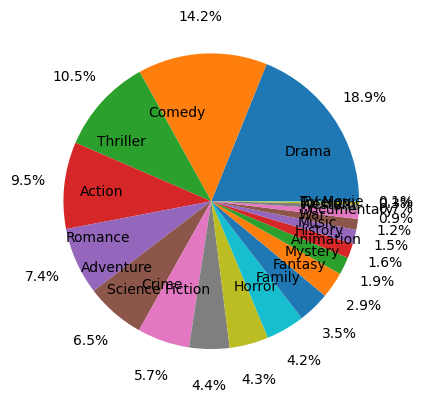

In [400]:
fig, ax = plt.subplots()
ax.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%',
       pctdistance=1.25, labeldistance=.6)

plt.show()

In [401]:
#Is there a relationship between budget and revenue?
df[['budget', 'revenue']].corr()

,budget,revenue
budget,1.000000,0.730806
revenue,0.730806,1.000000


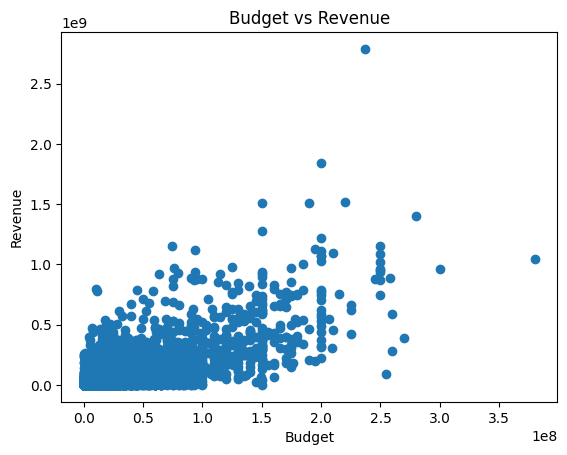

In [402]:
# Is there a relationship between budget and revenue?
plt.scatter(df['budget'], df['revenue'])
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.title('Budget vs Revenue')
plt.show()

In [403]:
df[['vote_average', 'revenue']].corr()

,vote_average,revenue
vote_average,1.000000,0.197153
revenue,0.197153,1.000000


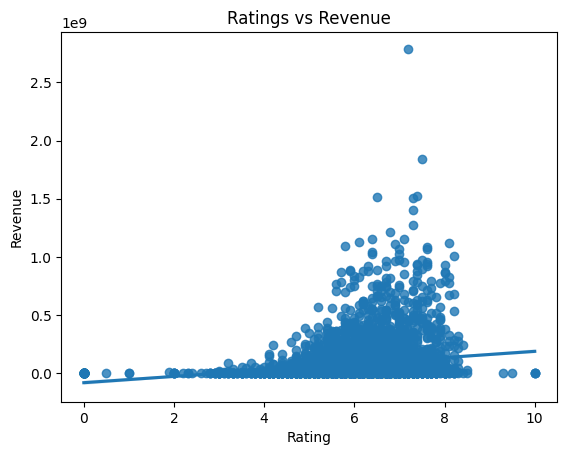

In [404]:
sns.regplot(x='vote_average', y='revenue', data=df)

plt.title('Ratings vs Revenue')
plt.xlabel('Rating')
plt.ylabel('Revenue')
plt.show()
# corr that are better than person corr

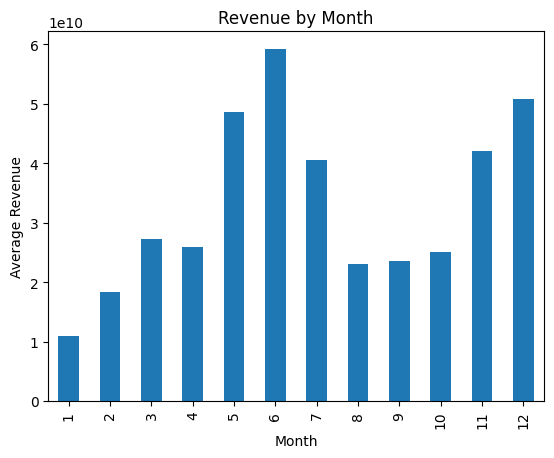

In [405]:
# how month affects of movie revenue
month_rev = df.groupby('month')['revenue'].sum()
month_rev.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.title('Revenue by Month')
plt.show()

In [406]:
# Top 10 highest revenue
top_rev = df[['original_title', 'revenue']].sort_values(by='revenue', ascending=False).head(10)
top_rev

,original_title,revenue
0,Avatar,2787965087
25,Titanic,1845034188
16,The Avengers,1519557910
28,Jurassic World,1513528810
44,Furious 7,1506249360
7,Avengers: Age of Ultron,1405403694
124,Frozen,1274219009
31,Iron Man 3,1215439994
546,Minions,1156730962
26,Captain America: Civil War,1153304495


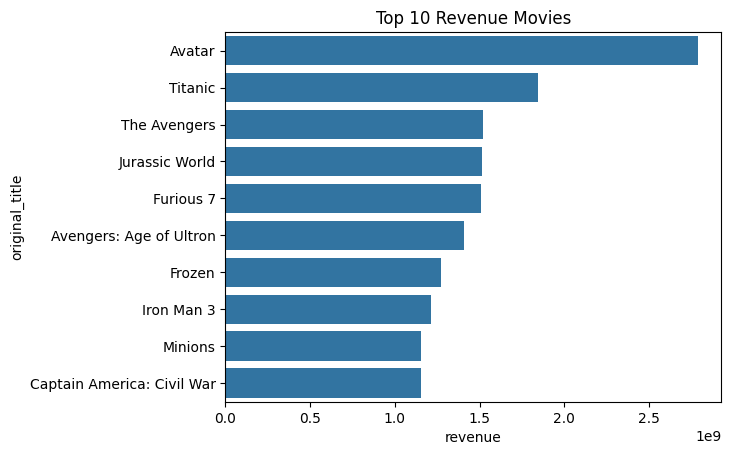

In [407]:
sns.barplot(x=top_rev['revenue'], y=top_rev['original_title'])
plt.title('Top 10 Revenue Movies')
plt.show()

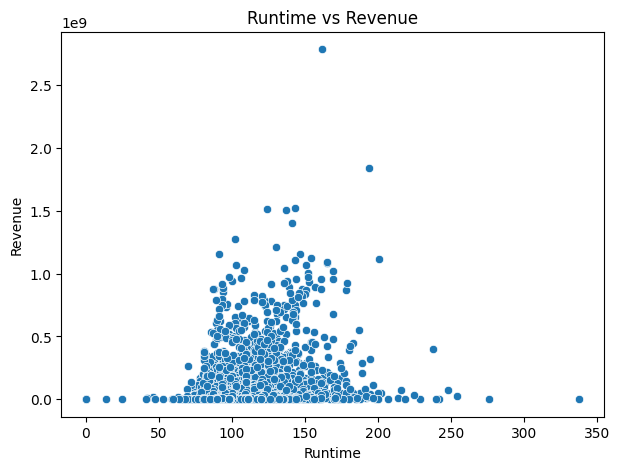

In [408]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="runtime",
    y="revenue"
)

plt.title("Runtime vs Revenue")
plt.xlabel("Runtime")
plt.ylabel("Revenue")

plt.show()

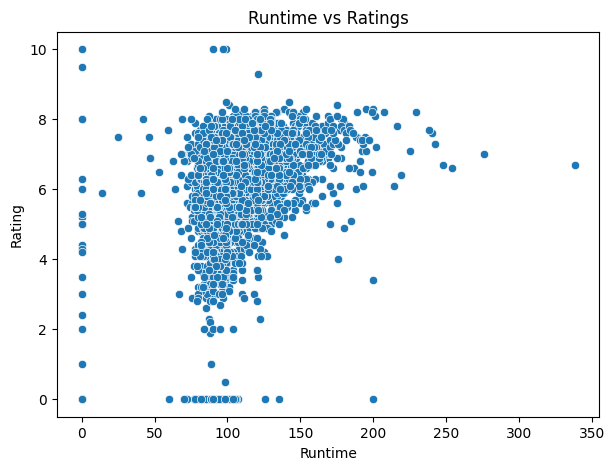

In [409]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="runtime",
    y="vote_average"
)

plt.title("Runtime vs Ratings")
plt.xlabel("Runtime")
plt.ylabel("Rating")

plt.show()